<a href="https://colab.research.google.com/github/AyleenSantander/M.11_Intro_AI/blob/main/Project_5_Basic_NLP_with_Unsupervised_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Project 5: Basic Natural Language Processing with Unsupervised Learning
#Name Ayleen Santander

#Part 1: Text Data Preparation
1. Load the Newsgroups dataset using scikit-learn.
2. Perform basic text preprocessing including tokenization, removing stopwords, and punctuation.

In [1]:
#Installation
%pip install ipykernel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 77.3 MB/s eta 0:00:00


In [2]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 39.0 MB/s eta 0:00:00


In [4]:
#Import Libraries and dataset
import sys
print(sys.version)
print(sys.executable)
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import nltk
import re
import string
import tensorflow as tf
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
nltk.download("stopwords"); nltk.download("punkt")
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import gensim.downloader as api
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (silhouette_score, adjusted_rand_score,
                             normalized_mutual_info_score)
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.metrics import silhouette_samples
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA

RANDOM_STATE = 42

STOPWORDS = set(stopwords.words("english"))
print(tf.__version__)

3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
/usr/bin/python3
2.20.0


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [5]:
#1. Load Dataset
newsgroups = fetch_20newsgroups(
    subset="train",
    remove=("headers", "footers", "quotes"),
    random_state=42,
)

print("Number of documents:", len(newsgroups.data))
print("Number of categories:", len(newsgroups.target_names))
print("Categories:", newsgroups.target_names)

Number of documents: 11314
Number of categories: 20
Categories: ['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball', 'rec.sport.hockey', 'sci.crypt', 'sci.electronics', 'sci.med', 'sci.space', 'soc.religion.christian', 'talk.politics.guns', 'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc']


In [6]:
# Put it in a DataFrame for easier handling
ng = pd.DataFrame({
    "text": newsgroups.data,
    "target": newsgroups.target,
})
ng["category"] = ng["target"].apply(lambda i: newsgroups.target_names[i])

print(ng.head())

                                                text  target  \
0  I was wondering if anyone out there could enli...       7   
1  A fair number of brave souls who upgraded thei...       4   
2  well folks, my mac plus finally gave up the gh...       4   
3  \nDo you have Weitek's address/phone number?  ...       1   
4  From article <C5owCB.n3p@world.std.com>, by to...      14   

                category  
0              rec.autos  
1  comp.sys.mac.hardware  
2  comp.sys.mac.hardware  
3          comp.graphics  
4              sci.space  


In [7]:
# Look at a few example documents
for i in [0, 5, 10]:
    print(f"--- Document {i} | Category: {ng.loc[i, 'category']} ---")
    print(ng.loc[i, "text"][:300], "\n")

--- Document 0 | Category: rec.autos ---
I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I k 

--- Document 5 | Category: talk.politics.guns ---





Of course.  The term must be rigidly defined in any bill.


I doubt she uses this term for that.  You are using a quote allegedly
from her, can you back it up?




I read the article as presenting first an argument about weapons of mass
destruction (as commonly understood) and then switching to 

--- Document 10 | Category: rec.motorcycles ---
I have a line on a Ducati 900GTS 1978 model with 17k on the clock.  Runs
very well, paint is the bronze/brown/orange faded out, leaks a bit of oil
and pops out of 1st with hard accel.  The shop will fix trans and oil 
leak.  They sold the bike to the 1 an

Note:
Why can't we simply give the original text to K-Means?
K-Means groups data by measuring distances between points. Raw text is just words, and there is no way to calculate a distance between two sentences. The text must first be converted into numbers (for example with TF-IDF) so every document becomes a vector that K-Means can compare.

In [8]:
# 2. Preprocessing function
STOPWORDS = set(ENGLISH_STOP_WORDS)
PUNCT_TABLE = str.maketrans("", "", string.punctuation)

def preprocess(text):
    # Lowercase
    text = text.lower()
    # Remove punctuation
    text = text.translate(PUNCT_TABLE)
    # Remove numbers and extra whitespace
    text = re.sub(r"\d+", " ", text)
    # Tokenize (split into words)
    tokens = text.split()
    # Remove stopwords and very short tokens
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 2]
    return tokens

In [9]:
# 3. Apply preprocessing
ng["tokens"] = ng["text"].apply(preprocess)
ng["clean_text"] = ng["tokens"].apply(" ".join)

# Drop documents that became empty after cleaning
ng = ng[ng["clean_text"].str.len() > 0].reset_index(drop=True)

In [10]:
# 4. Check the results
print("\nDocuments after cleaning:", len(ng))
print("\n--- ORIGINAL ---")
print(newsgroups.data[0][:400])
print("\n--- TOKENS ---")
print(ng.loc[0, "tokens"][:30])


Documents after cleaning: 10992

--- ORIGINAL ---
I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, h

--- TOKENS ---
['wondering', 'enlighten', 'car', 'saw', 'day', 'door', 'sports', 'car', 'looked', 'late', 'early', 'called', 'bricklin', 'doors', 'really', 'small', 'addition', 'bumper', 'separate', 'rest', 'body', 'know', 'tellme', 'model', 'engine', 'specs', 'years', 'production', 'car', 'history']


In [11]:
# Top 20 most common words across the whole corpus
all_tokens = pd.Series([t for tokens in ng["tokens"] for t in tokens])
print("\nTop 20 words:")
print(all_tokens.value_counts().head(20))


Top 20 words:
people                             3997
like                               3885
dont                               3862
just                               3747
know                               3482
maxaxaxaxaxaxaxaxaxaxaxaxaxaxax    3317
use                                3161
think                              2999
time                               2800
does                               2773
new                                2571
good                               2474
make                               2022
way                                1992
used                               1865
say                                1844
right                              1810
did                                1757
said                               1739
want                               1737
Name: count, dtype: int64


#Parat 2: Text Representation
1. Implement Bag of Words and TF-IDF for feature extraction.
2. Introduce basic word embeddings and illustrate with a simple pre-trained example, if feasible.

In [13]:
vectorizer = TfidfVectorizer(stop_words="english", max_features=5000)
X = vectorizer.fit_transform(ng["text"])

In [14]:
#1. Toy example: see the difference on 3 short sentences
toy_docs = [
    "the car engine is fast",
    "the car has a new engine",
    "the team won the hockey game",
]

toy_bow = CountVectorizer()
toy_bow_matrix = toy_bow.fit_transform(toy_docs)
print("BAG OF WORDS (word counts):")
print(pd.DataFrame(toy_bow_matrix.toarray(),columns=toy_bow.get_feature_names_out()))

toy_tfidf = TfidfVectorizer()
toy_tfidf_matrix = toy_tfidf.fit_transform(toy_docs)
print("\nTF-IDF (weighted scores):")
print(pd.DataFrame(toy_tfidf_matrix.toarray().round(2),columns=toy_tfidf.get_feature_names_out()))

BAG OF WORDS (word counts):
   car  engine  fast  game  has  hockey  is  new  team  the  won
0    1       1     1     0    0       0   1    0     0    1    0
1    1       1     0     0    1       0   0    1     0    1    0
2    0       0     0     1    0       1   0    0     1    2    1

TF-IDF (weighted scores):
    car  engine  fast  game   has  hockey    is   new  team   the   won
0  0.41    0.41  0.53  0.00  0.00    0.00  0.53  0.00  0.00  0.32  0.00
1  0.41    0.41  0.00  0.00  0.53    0.00  0.00  0.53  0.00  0.32  0.00
2  0.00    0.00  0.00  0.43  0.00    0.43  0.00  0.00  0.43  0.51  0.43


Note:
short version

Bag of Words counts how often each word appears. TF-IDF gives higher scores to words that are rare across documents and lower scores to common words like "the,"which appears in all three.

Both show rows 0 and 1 are about cars and row 2 is about hockey, but TF-IDF is better for clustering because it highlights the words that define each topic.

In [15]:
# 2. Bag of Words on the full dataset
bow_vectorizer = CountVectorizer(
    max_features=5000,  # keep the 5,000 most frequent words
    min_df=5,           # ignore words appearing in fewer than 5 docs
    max_df=0.9,         # ignore words appearing in more than 90% of docs
)
X_bow = bow_vectorizer.fit_transform(ng["clean_text"])

print("\nBoW matrix shape (documents x words):", X_bow.shape)
sparsity = 1 - X_bow.nnz / (X_bow.shape[0] * X_bow.shape[1])
print(f"Sparsity: {sparsity:.2%} of values are zero")

# Most frequent words overall
word_counts = np.asarray(X_bow.sum(axis=0)).ravel()
bow_top = pd.Series(word_counts, index=bow_vectorizer.get_feature_names_out())
print("\nTop 15 words by count:")
print(bow_top.sort_values(ascending=False).head(15))


BoW matrix shape (documents x words): (10992, 5000)
Sparsity: 99.15% of values are zero

Top 15 words by count:
people                             3997
like                               3885
dont                               3862
just                               3747
know                               3482
maxaxaxaxaxaxaxaxaxaxaxaxaxaxax    3317
use                                3161
think                              2999
time                               2800
does                               2773
new                                2571
good                               2474
make                               2022
way                                1992
used                               1865
dtype: int64


Explanation:
The matrix has 10,992 documents and 5,000 words. It's 99% zeros because each post uses only a small share of the vocabulary, which is normal for text.

The top words (people, like, dont, just) are generic everyday words, not topic words. That's why TF-IDF works better for clustering: it lowers the weight of words used everywhere.

One thing to fix: maxaxaxax... is junk from encoded files (images or attachments) posted as text, not a real word.

In [56]:
#Fix the wear words
token_pattern=r"(?u)\b[a-zA-Z]{2,20}\b)"

bow_vec = CountVectorizer(stop_words="english", max_features=5000,
                          token_pattern=r"(?u)\b[a-zA-Z]{2,20}\b")
X_bow = bow_vec.fit_transform(ng["text"])
vocab = bow_vec.get_feature_names_out()

# Checks
print("Shape:", X_bow.shape)
print("Longest word:", max(len(w) for w in vocab))
print("Junk words found:", [w for w in vocab if "axax" in w])

Shape: (10992, 5000)
Longest word: 18
Junk words found: []


In [58]:
# 3. TF-IDF on the full dataset
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=5,
    max_df=0.9,
)
X_tfidf = tfidf_vectorizer.fit_transform(ng["clean_text"])
feature_names = tfidf_vectorizer.get_feature_names_out()
print("\nTF-IDF matrix shape:", X_tfidf.shape)


TF-IDF matrix shape: (10992, 5000)


In [59]:
print("Number of documents:", X_tfidf.shape[0])
print("Number of features:", X_tfidf.shape[1])
print("Sample feature names:", feature_names[1000:1020])

Number of documents: 10992
Number of features: 5000
Sample feature names: ['cool' 'cooling' 'cooper' 'cooperation' 'cop' 'copies' 'coprocessor'
 'cops' 'copy' 'copyright' 'core' 'corn' 'corner' 'corp' 'corporation'
 'corps' 'corpses' 'correct' 'corrected' 'correction']


In [60]:
# Top TF-IDF terms for a single document
doc_id = 0
doc_scores = pd.Series(X_tfidf[doc_id].toarray().ravel(), index=tfidf_vectorizer.get_feature_names_out())
print(f"\nDocument {doc_id} category: {ng.loc[doc_id, 'category']}")
print("Top 10 TF-IDF terms:")
print(doc_scores.sort_values(ascending=False).head(10).round(3))


Document 0 category: rec.autos
Top 10 TF-IDF terms:
car           0.577
doors         0.213
sports        0.205
production    0.201
specs         0.201
door          0.184
separate      0.180
engine        0.178
addition      0.173
late          0.171
dtype: float64


In [61]:
# Top TF-IDF terms per category (shows what makes each group distinct)
feature_names = tfidf_vectorizer.get_feature_names_out()
print("\nTop 5 TF-IDF terms per category:")
for cat in sorted(ng["category"].unique()):
    rows = np.where(ng["category"] == cat)[0]
    mean_scores = np.asarray(X_tfidf[rows].mean(axis=0)).ravel()
    top_terms = feature_names[mean_scores.argsort()[::-1][:5]]
    print(f"{cat:<28} {', '.join(top_terms)}")


Top 5 TF-IDF terms per category:
alt.atheism                  god, people, dont, think, religion
comp.graphics                graphics, thanks, image, files, file
comp.os.ms-windows.misc      windows, file, dos, files, driver
comp.sys.ibm.pc.hardware     drive, card, scsi, controller, ide
comp.sys.mac.hardware        mac, apple, drive, thanks, problem
comp.windows.x               window, server, motif, use, thanks
misc.forsale                 sale, offer, shipping, email, condition
rec.autos                    car, cars, like, engine, just
rec.motorcycles              bike, dod, bikes, ride, motorcycle
rec.sport.baseball           year, team, baseball, game, games
rec.sport.hockey             game, team, hockey, players, games
sci.crypt                    key, encryption, clipper, chip, keys
sci.electronics              use, circuit, like, power, does
sci.med                      msg, gordon, chastity, jxp, gebcadredslpittedu
sci.space                    space, nasa, orbit, launch, mo

In [62]:
#K-Means with K = 5
K5 = 5
kmeans5 = KMeans(n_clusters=K5, n_init=10, random_state=RANDOM_STATE)
ng["cluster_k5"] = kmeans5.fit_predict(X_tfidf)

print("Cluster assignments (first 10 docs):")
print(ng[["category", "cluster_k5"]].head(10))

print("\nDocuments per cluster:")
print(ng["cluster_k5"].value_counts().sort_index())

Cluster assignments (first 10 docs):
                   category  cluster_k5
0                 rec.autos           0
1     comp.sys.mac.hardware           0
2     comp.sys.mac.hardware           2
3             comp.graphics           0
4                 sci.space           0
5        talk.politics.guns           0
6                   sci.med           2
7  comp.sys.ibm.pc.hardware           2
8   comp.os.ms-windows.misc           0
9     comp.sys.mac.hardware           2

Documents per cluster:
cluster_k5
0    5429
1     517
2    1962
3     737
4    2347
Name: count, dtype: int64


Explanation:
Each post got a cluster number from 0 to 4. Posts from very different topics ended up in the same cluster, so the clusters don't match the 20 real categories well.

Cluster 0 holds about half the posts, acting as a catch-all, while clusters 1 and 3 are small and focused. This suggests 5 clusters is too few, which supports using a higher k like 10.

In [21]:
#Order = kmeans5. clusters
K5 = 5
kmeans5 = KMeans(n_clusters=K5, random_state=42, n_init=10)
kmeans5.fit(X_tfidf)

feature_names = vectorizer.get_feature_names_out()
order = kmeans5.cluster_centers_.argsort()[:, ::-1]
for c in range(K5):
    words = [feature_names[i] for i in order[c, :10]]
    print(f"Cluster {c}: {', '.join(words)}")

Cluster 0: knowledge, interference, monthly, forget, aware, ux, dave, title, israeli, indicate
Cluster 1: fool, inhabitants, americans, bitmap, allen, birth, emphasis, bios, originally, black
Cluster 2: th, wires, default, away, israeli, dave, europe, ux, device, dean
Cluster 3: figured, teaching, figures, ye, peace, satan, greater, pcs, jumpers, teachings
Cluster 4: originally, dealer, thoughts, interference, israeli, knowledge, formed, row, reserve, involve


In [63]:
# Look at 3 documents from each cluster
for c in range(K5):
    print(f"\n===== CLUSTER {c} =====")
    samples = ng[ng["cluster_k5"] == c].sample(3, random_state=RANDOM_STATE)
    for _, row in samples.iterrows():
        print(f"[{row['category']}] {row['text'][:200].strip()}\n")


===== CLUSTER 0 =====
[sci.space] So how much would it cost as a private venture, assuming you could talk the
U.S. government into leasing you a couple of pads in Florida?

[soc.religion.christian] Hmmm.  Here's food for thought:  " ...but rather be in fear of him
who can destroy both soul and body in gehenna."  Math 10:28

[rec.autos] they are pretty much junk, stay away from them.  they will be replaced next
year with all new models.


===== CLUSTER 1 =====
[soc.religion.christian] I'll take a try at this...

From the discussions I have been in, and from how *I* have interpreted
the bible, I feel that one can pray either way.  BUT remember this,
before Jesus, the people talked

[soc.religion.christian] [text deleted]

I wish that you had followed this thread before jumping to conclusions.
I haven't seen anybody write that AIDS was a *punishment* for certain
types of sin (this includes Mark Ashley wh

[soc.religion.christian] Hi,

I am new to this newsgroup, and also fairly new to ch

Note:
Do the documents within each cluster appear to discuss similar topics?
Partly. Clusters with specific vocabulary (for example religion or computers) contain documents that clearly discuss the same subject. The largest cluster mixes many categories because it is built on everyday words like "like", "just" and "know", so its documents are not very similar.

In [64]:
# Which real categories ended up in each cluster (labels used only to check)
for c in range(K5):
    top_cats = ng[ng["cluster_k5"] == c]["category"].value_counts().head(3)
    print(f"Cluster {c}: {dict(top_cats)}")

Cluster 0: {'rec.motorcycles': np.int64(473), 'rec.autos': np.int64(456), 'sci.electronics': np.int64(452)}
Cluster 1: {'soc.religion.christian': np.int64(319), 'talk.religion.misc': np.int64(96), 'alt.atheism': np.int64(90)}
Cluster 2: {'comp.sys.ibm.pc.hardware': np.int64(395), 'comp.os.ms-windows.misc': np.int64(395), 'comp.sys.mac.hardware': np.int64(278)}
Cluster 3: {'rec.sport.hockey': np.int64(412), 'rec.sport.baseball': np.int64(293), 'misc.forsale': np.int64(20)}
Cluster 4: {'sci.crypt': np.int64(392), 'talk.politics.mideast': np.int64(359), 'talk.politics.guns': np.int64(319)}


In [65]:
# Topic table for K = 5
k5_words = tfidf_vectorizer.get_feature_names_out()
order5 = kmeans5.cluster_centers_.argsort()[:, ::-1]

# Topic names chosen by looking at the top words and sample documents
topic_names = {
    0: "General / catch-all",
    1: "Religion",
    2: "Computers",
    3: "Sports",
    4: "Politics and encryption",
}

rows = []
for c in range(K5):
    cluster_docs = ng[ng["cluster_k5"] == c]
    top_cats = cluster_docs["category"].value_counts().head(3).index
    rows.append({
        "Cluster": c,
        "Size": len(cluster_docs),
        "Common Words": ", ".join(k5_words[i] for i in order5[c, :6]),
        "Main Categories": ", ".join(top_cats),
        "Possible Topic": topic_names[c],
    })

topic_table = pd.DataFrame(rows).set_index("Cluster")
pd.set_option("display.max_colwidth", 100)
topic_table

,Size,Common Words,Main Categories,Possible Topic
Cluster,,,,
0,5429,"like, just, new, good, car, use","rec.motorcycles, rec.autos, sci.electronics",General / catch-all
1,517,"god, jesus, bible, christians, believe, christian","soc.religion.christian, talk.religion.misc, alt.atheism",Religion
2,1962,"thanks, windows, drive, card, know, does","comp.sys.ibm.pc.hardware, comp.os.ms-windows.misc, comp.sys.mac.hardware",Computers
3,737,"game, team, games, year, players, season","rec.sport.hockey, rec.sport.baseball, misc.forsale",Sports
4,2347,"people, dont, think, just, know, like","sci.crypt, talk.politics.mideast, talk.politics.guns",Politics and encryption


Explanation:
This table summarizes what each of the 5 clusters is about, using its size, most common words, and the real categories it contains most.

Three clusters found clear topics: Religion (1), Computers (2), and Sports (3). Their top words match well, like god, jesus, bible and game, team, season.

Cluster 0 is a catch-all. Its words (like, just, good) are generic, and it mixes cars, motorcycles, and electronics. Cluster 4 combines politics and encryption because those posts share argument-style words like people, think, dont.

The takeaway: k = 5 finds a few strong topics but merges others, which supports trying a higher k.

In [26]:
#Word embeddings with pre-trained GloVe vectors
glove = api.load("glove-wiki-gigaword-50")

print("\nVector for 'computer' (first 10 of 50 numbers):")
print(glove["computer"][:10].round(3))


Vector for 'computer' (first 10 of 50 numbers):
[ 0.079 -0.815  1.79   0.917  0.108 -0.556 -0.844 -1.495  0.134  0.636]


In [67]:
# Similar words: embeddings capture meaning, not just spelling
for word in ["car", "hockey", "god", "windows"]:
    similar = [w for w, _ in glove.most_similar(word, topn=5)]
    print(f"Most similar to '{word}': {similar}")

Most similar to 'car': ['truck', 'cars', 'vehicle', 'driver', 'driving']
Most similar to 'hockey': ['basketball', 'football', 'soccer', 'league', 'leagues']
Most similar to 'god': ['divine', 'heaven', 'christ', 'faith', 'allah']
Most similar to 'windows': ['window', 'console', 'desktop', 'doors', 'portable']


In [68]:
# Similarity scores (1 = identical meaning, 0 = unrelated)
print("\nSimilarity car vs automobile:", round(glove.similarity("car", "automobile"), 3))
print("Similarity car vs banana:    ", round(glove.similarity("car", "banana"), 3))


Similarity car vs automobile: 0.696
Similarity car vs banana:     0.219


In [69]:
# Classic analogy: king - man + woman = ?
result = glove.most_similar(positive=["king", "woman"], negative=["man"], topn=1)
print("\nking - man + woman =", result[0][0])


king - man + woman = queen


In [70]:
# 5. Document embeddings: average the word vectors in each post
def doc_vector(tokens, model):
    vectors = [model[t] for t in tokens if t in model]
    if not vectors:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)


X_embed = np.vstack(ng["tokens"].apply(lambda toks: doc_vector(toks, glove)))
print("\nEmbedding matrix shape:", X_embed.shape)


Embedding matrix shape: (10992, 50)


In [71]:
# 6. Quick comparison of the three representations
summary = pd.DataFrame({
    "Method": ["Bag of Words", "TF-IDF", "GloVe average"],
    "Features": [X_bow.shape[1], X_tfidf.shape[1], X_embed.shape[1]],
    "Type": ["Sparse counts", "Sparse weights", "Dense vectors"],
    "Captures meaning?": ["No", "No", "Yes (similar words are close)"],
})
print("\n", summary.to_string(index=False))


        Method  Features           Type             Captures meaning?
 Bag of Words      5000  Sparse counts                            No
       TF-IDF      5000 Sparse weights                            No
GloVe average        50  Dense vectors Yes (similar words are close)


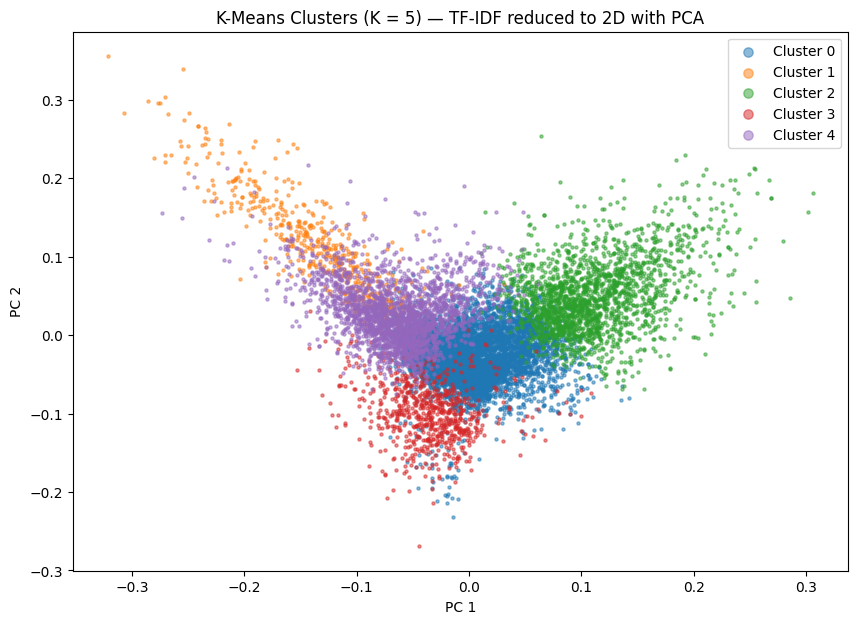

Variance explained by 2 components: 0.01


In [72]:
#PCA visualization
pca = PCA(n_components=2, svd_solver="arpack", random_state=RANDOM_STATE)
coords_pca = pca.fit_transform(X_tfidf)   # if this errors, use X_tfidf.toarray()

plt.figure(figsize=(10, 7))
for c in range(K5):
    mask = ng["cluster_k5"] == c
    plt.scatter(coords_pca[mask, 0], coords_pca[mask, 1], s=5, alpha=0.5, label=f"Cluster {c}")
plt.title("K-Means Clusters (K = 5) — TF-IDF reduced to 2D with PCA")
plt.xlabel("PC 1"); plt.ylabel("PC 2")
plt.legend(markerscale=3)
plt.show()

print("Variance explained by 2 components:", pca.explained_variance_ratio_.sum().round(3))

Note:
1. Are some clusters clearly separated? Yes, partly. Cluster 2 (computers) spreads to the right and Cluster 1 (religion) spreads to the upper left, in opposite directions. Cluster 3 (sports) extends downward.
2. Are some overlapping? Yes. Clusters 0 and 4 overlap heavily in the center, and all clusters touch near the middle.
3. What does this tell us? Text topics have soft borders. Documents with specific vocabulary separate well, while general posts share common words and sit in the center. Two components explain only about 1% of the variance, so the real separation in 5,000 dimensions is better than the plot shows.

#Part 3: Unsupervised Learning Application
1. Apply clustering algorithms like K-Means or
2. Hierarchical Clustering to the extracted features.
3. Analyze and interpret the resulting clusters, examining common themes or topics within each cluster.

In [73]:
# 1. Choose the number of clusters (elbow + silhouette)
k_values = [5, 10, 15, 20, 25, 30]
inertias, silhouettes = [], []

for k in k_values:
    km = KMeans(n_clusters=k, n_init=5, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_tfidf)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_tfidf, labels, sample_size=3000,
                                        random_state=RANDOM_STATE))
    print(f"k={k:<3} inertia={km.inertia_:,.0f}  silhouette={silhouettes[-1]:.4f}")


k=5   inertia=10,697  silhouette=0.0038
k=10  inertia=10,580  silhouette=0.0078
k=15  inertia=10,528  silhouette=0.0087
k=20  inertia=10,464  silhouette=0.0098
k=25  inertia=10,415  silhouette=0.0106
k=30  inertia=10,365  silhouette=0.0109


Explanation:
Inertia measures how tight the clusters are (lower is better). It drops a little with each higher k, but there's no sharp "elbow" where it suddenly levels off.
Silhouette measures how well-separated the clusters are (higher is better). It doubles from k = 5 to k = 10, then grows much more slowly.

k = 10 is the best balance, since it gives the biggest improvement before gains slow down. All silhouette scores are very low (near 0), which is normal for text data because topics share many words.

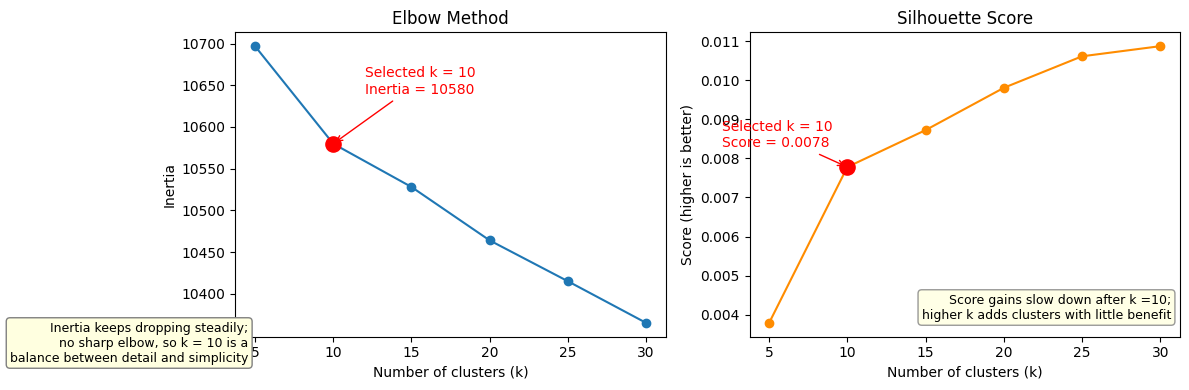

In [36]:
best_k = 10
idx = list(k_values).index(best_k)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Elbow chart
axes[0].plot(k_values, inertias, marker="o")
axes[0].scatter(best_k, inertias[idx], color="red", s=120, zorder=5)
axes[0].annotate(f"Selected k = {best_k}\nInertia = {inertias[idx]:.0f}",
                 xy=(best_k, inertias[idx]),
                 xytext=(best_k + 2, inertias[idx] + 60),
                 arrowprops=dict(arrowstyle="->", color="red"),
                 color="red", fontsize=10)
axes[0].text(0.03, 0.05, "Inertia keeps dropping steadily;\nno sharp elbow, so k = 10 is a\nbalance between detail and simplicity",
             transform=axes[0].transAxes, ha="right", va="top", fontsize=9,
             bbox=dict(boxstyle="round", facecolor="lightyellow", edgecolor="gray"))
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")

# Silhouette chart
axes[1].plot(k_values, silhouettes, marker="o", color="darkorange")
axes[1].scatter(best_k, silhouettes[idx], color="red", s=120, zorder=5)
axes[1].annotate(f"Selected k = {best_k}\nScore = {silhouettes[idx]:.4f}",
                 xy=(best_k, silhouettes[idx]),
                 xytext=(best_k - 8, silhouettes[idx] + 0.0005),
                 arrowprops=dict(arrowstyle="->", color="red"),
                 color="red", fontsize=10)
axes[1].text(0.98, 0.05, "Score gains slow down after k =10;\nhigher k adds clusters with little benefit",
             transform=axes[1].transAxes, ha="right", va="bottom", fontsize=9,
             bbox=dict(boxstyle="round", facecolor="lightyellow", edgecolor="gray", alpha=0.8))
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Score (higher is better)")

plt.tight_layout()
plt.show()

In [74]:
# 2. extension: K-Means with k = 10
K = 10
kmeans = KMeans(n_clusters=K, n_init=10, random_state=RANDOM_STATE)
ng["kmeans_cluster"] = kmeans.fit_predict(X_tfidf)

print("\nDocuments per cluster:")
print(ng["kmeans_cluster"].value_counts().sort_index())


Documents per cluster:
kmeans_cluster
0     707
1    2068
2     268
3      71
4     483
5     289
6     402
7    5155
8     786
9     763
Name: count, dtype: int64


Explanation:
Cluster 7 is still a catch-all, holding about half the posts (5,155 of 10,992), so generic posts still group together even with more clusters. Most other clusters are mid-sized (268 to 2,068), which suggests they captured more specific topics than k = 5 did.

Cluster 3 is very small (71 posts), so it's probably one narrow topic or a group of unusual posts. Check its top words to see which.

"Moving to k = 10 split the data into more focused topics, but one large catch-all cluster remains."

In [75]:
# 3. Interpret K-Means clusters: top terms per cluster
def top_terms_from_centroids(model, n_terms=10):
    order = model.cluster_centers_.argsort()[:, ::-1]
    return {c: [feature_names[i] for i in order[c, :n_terms]]
            for c in range(model.n_clusters)}


kmeans_terms = top_terms_from_centroids(kmeans)

In [76]:
# Dominant true category in each cluster
dominant = (ng.groupby("kmeans_cluster")["category"]
              .agg(lambda s: s.value_counts().index[0]))
purity = (ng.groupby("kmeans_cluster")["category"]
            .agg(lambda s: s.value_counts(normalize=True).iloc[0]))

cluster_summary = pd.DataFrame({
    "size": ng["kmeans_cluster"].value_counts().sort_index(),
    "top_terms": [", ".join(kmeans_terms[c][:8]) for c in range(K)],
    "dominant_category": dominant,
    "purity": purity.round(2),
})
pd.set_option("display.max_colwidth", 80)
print("\nK-MEANS CLUSTER SUMMARY")
print(cluster_summary.to_string())


K-MEANS CLUSTER SUMMARY
                size                                                                              top_terms         dominant_category  purity
kmeans_cluster                                                                                                                               
0                707                                 game, team, games, year, players, season, hockey, play          rec.sport.hockey    0.57
1               2068                               people, dont, just, think, like, know, right, government     talk.politics.mideast    0.17
2                268                               drive, scsi, drives, hard, disk, floppy, ide, controller  comp.sys.ibm.pc.hardware    0.43
3                 71  gebcadredslpittedu, chastity, jxp, shameful, intellect, skepticism, surrender, gordon                   sci.med    1.00
4                483                       god, jesus, bible, christians, believe, faith, christ, christian    soc.religion

In [77]:
# 4. Compare clusters with the real categories
ari = adjusted_rand_score(ng["target"], ng["kmeans_cluster"])
nmi = normalized_mutual_info_score(ng["target"], ng["kmeans_cluster"])
print(f"\nAdjusted Rand Index: {ari:.3f}  (0 = random, 1 = perfect match)")
print(f"Normalized Mutual Info: {nmi:.3f}  (0 = no overlap, 1 = perfect match)")



Adjusted Rand Index: 0.052  (0 = random, 1 = perfect match)
Normalized Mutual Info: 0.266  (0 = no overlap, 1 = perfect match)


Note:
ARI = 0.052: very close to random, so few pairs of posts are grouped the same way as the true labels. The big catch-all cluster pulls this down.
NMI = 0.266: some real overlap. The clusters do capture part of the topic structure, like religion, computers, and sports.

The clustering found some real topics but doesn't match the 20 categories closely. That's expected, since K-Means used 10 clusters for 20 categories, many of which overlap (for example, the several computer groups).

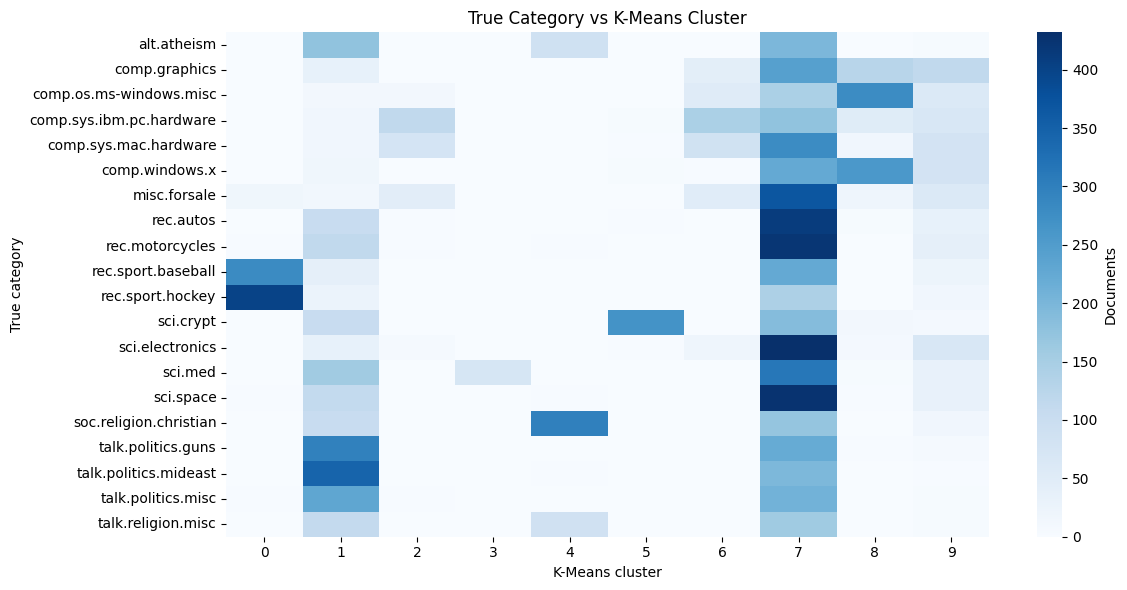

In [41]:
crosstab = pd.crosstab(ng["category"], ng["kmeans_cluster"])
plt.figure(figsize=(12, 6))
sns.heatmap(crosstab, cmap="Blues", cbar_kws={"label": "Documents"})
plt.title("True Category vs K-Means Cluster")
plt.xlabel("K-Means cluster")
plt.ylabel("True category")
plt.tight_layout(); plt.show()

Explanation:
Some topics formed clear clusters: hockey and baseball (cluster 0), religion (cluster 4), encryption (cluster 5) and a small sci.med cluster (3). The politics groups share cluster 1, and the computer groups are split across clusters 2, 6, 8 and 9. Cluster 7 (5,155 posts) is a catch-all that holds most autos, motorcycles, electronics, space and for-sale posts.

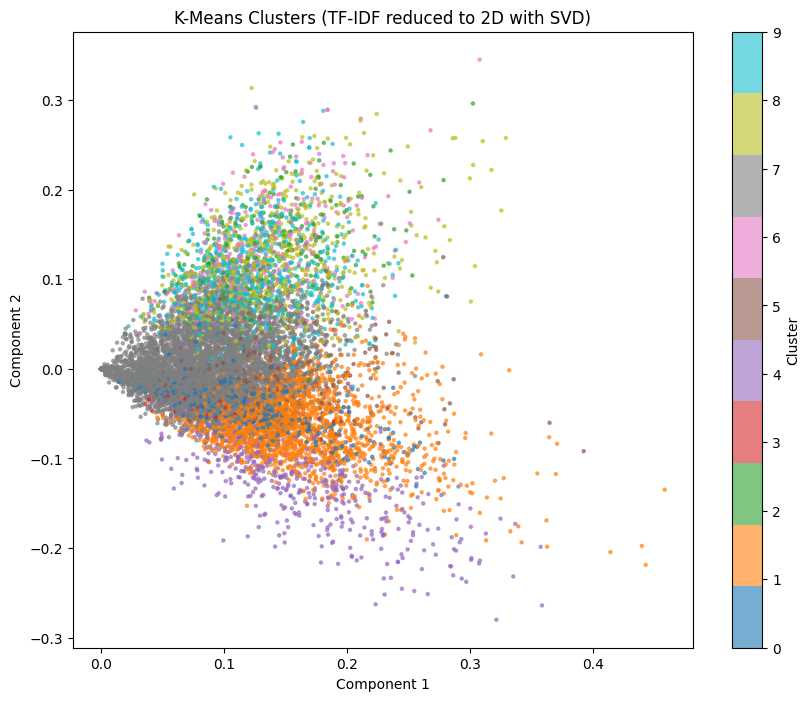

In [79]:
# 5. Visualize clusters in 2D
svd_2d = TruncatedSVD(n_components=2, random_state=RANDOM_STATE)
coords = svd_2d.fit_transform(X_tfidf)

plt.figure(figsize=(10, 8))
plt.scatter(coords[:, 0], coords[:, 1], c=ng["kmeans_cluster"],
            cmap="tab10", s=5, alpha=0.6)
plt.title("K-Means Clusters (TF-IDF reduced to 2D with SVD)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.colorbar(label="Cluster")
plt.show()

Explanation:
The picture is the same: gray (7, the catch-all) sits in the middle, orange (1, politics) and purple (4, religion) spread to the bottom, and the computer and science clusters (green, yellow, teal, pink) mix at the top. The overlap comes from squeezing all the text into 2D.

In [43]:
# 6. Hierarchical clustering (on a sample)
sample_idx = ng.sample(n=2000, random_state=RANDOM_STATE).index.to_numpy()
X_sample = X_tfidf[sample_idx]

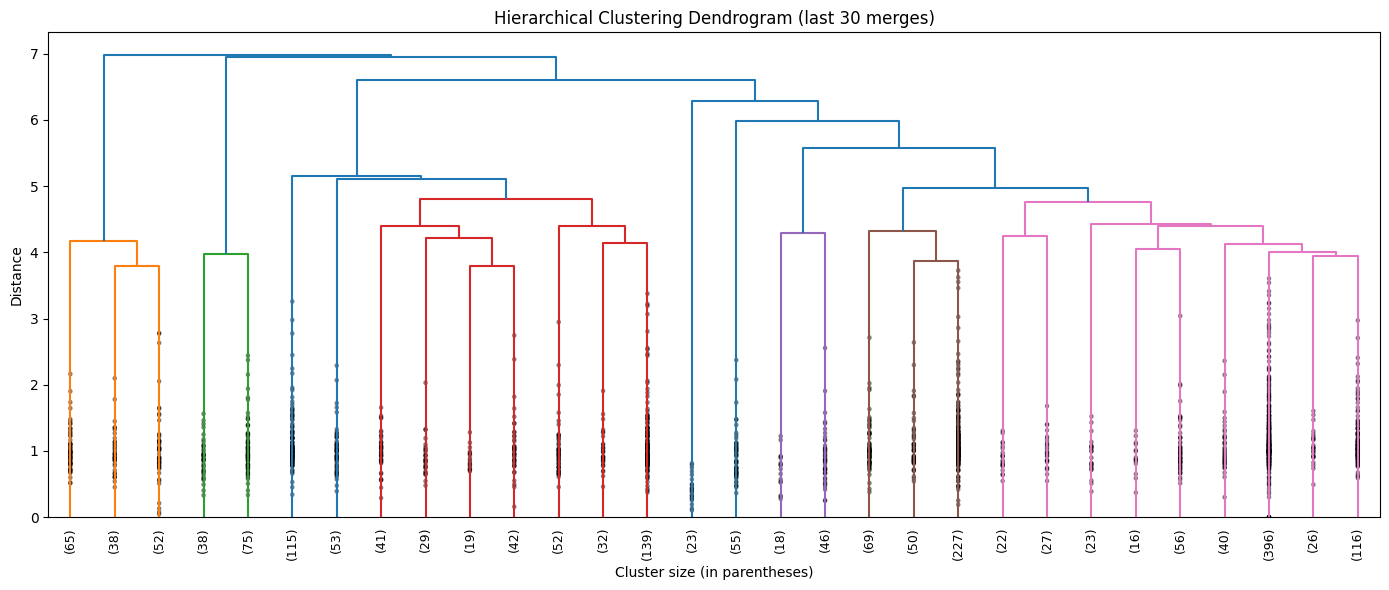

In [80]:
# Reduce to 100 dimensions first (LSA). Ward linkage needs dense data.
lsa = make_pipeline(TruncatedSVD(n_components=100, random_state=RANDOM_STATE),
                    Normalizer(copy=False))
X_sample_lsa = lsa.fit_transform(X_sample)

Z = linkage(X_sample_lsa, method="ward")

plt.figure(figsize=(14, 6))
dendrogram(Z, truncate_mode="lastp", p=30, leaf_rotation=90,
           leaf_font_size=9, show_contracted=True)
plt.title("Hierarchical Clustering Dendrogram (last 30 merges)")
plt.xlabel("Cluster size (in parentheses)")
plt.ylabel("Distance")
plt.tight_layout(); plt.show()

In [81]:
# Cut the tree into 10 clusters
sample_ng = ng.loc[sample_idx, ["category", "target"]].copy()
sample_ng["hier_cluster"] = fcluster(Z, t=K, criterion="maxclust")

In [82]:
# 7. Interpret hierarchical clusters
hier_rows = []
for c in sorted(sample_ng["hier_cluster"].unique()):
    positions = np.where(sample_ng["hier_cluster"].to_numpy() == c)[0]
    mean_scores = np.asarray(X_sample[positions].mean(axis=0)).ravel()
    top = feature_names[mean_scores.argsort()[::-1][:8]]
    cats = sample_ng.iloc[positions]["category"].value_counts(normalize=True)
    hier_rows.append({
        "cluster": c,
        "size": len(positions),
        "top_terms": ", ".join(top),
        "dominant_category": cats.index[0],
        "purity": round(cats.iloc[0], 2),
    })

hier_summary = pd.DataFrame(hier_rows).set_index("cluster")
print("\nHIERARCHICAL CLUSTER SUMMARY (2,000-doc sample)")
print(hier_summary.to_string())

hier_nmi = normalized_mutual_info_score(sample_ng["target"], sample_ng["hier_cluster"])
print(f"\nHierarchical NMI (sample): {hier_nmi:.3f}")


HIERARCHICAL CLUSTER SUMMARY (2,000-doc sample)
         size                                                                              top_terms         dominant_category  purity
cluster                                                                                                                               
1         155                                     game, team, year, season, play, games, fans, teams        rec.sport.baseball    0.44
2         113                             god, church, jesus, bible, christian, faith, people, think    soc.religion.christian    0.57
3         115                          thanks, does, information, anybody, know, code, info, advance            comp.windows.x    0.17
4          53                              drive, scsi, tape, controller, drives, floppy, ide, cdrom  comp.sys.ibm.pc.hardware    0.43
5         354                             windows, card, dos, using, file, problem, software, window   comp.os.ms-windows.misc    0.18
6     

Explanation:
Hierarchical clustering on the 2,000-post sample reached NMI 0.274, almost the same as K-Means (0.266). The purest clusters were sci.med (0.87), sci.crypt (0.84) and Middle East politics (0.81). Like K-Means, it produced a large mixed cluster (cluster 10, 722 posts, purity 0.10).

In [83]:
# 8. Bonus: K-Means on GloVe document embeddings
X_embed_norm = Normalizer().fit_transform(X_embed)
kmeans_embed = KMeans(n_clusters=K, n_init=10, random_state=RANDOM_STATE)
ng["embed_cluster"] = kmeans_embed.fit_predict(X_embed_norm)
embed_nmi = normalized_mutual_info_score(ng["target"], ng["embed_cluster"])

In [84]:
# 9. Final comparison
results = pd.DataFrame({
    "Method": ["K-Means + TF-IDF", "Hierarchical (Ward) + LSA", "K-Means + GloVe"],
    "Docs": [len(ng), len(sample_ng), len(ng)],
    "NMI vs true labels": [round(nmi, 3), round(hier_nmi, 3), round(embed_nmi, 3)],
})
print("\n", results.to_string(index=False))


                    Method  Docs  NMI vs true labels
         K-Means + TF-IDF 10992               0.266
Hierarchical (Ward) + LSA  2000               0.274
          K-Means + GloVe 10992               0.326


Explanation:
This compares how well three clustering methods match the real categories, using NMI (higher is better).

K-Means + GloVe scored best (0.326). GloVe represents words by meaning, so similar words like "car" and "vehicle" count as related. TF-IDF treats every word as separate, so it misses those links.

Hierarchical (0.274) and K-Means + TF-IDF (0.266) scored about the same. Keep in mind that hierarchical used only 2,000 posts, so the comparison isn't fully fair.

Using word meaning (GloVe) improved clustering more than switching the algorithm did.

#Part 4: Model Evaluation and Prediction
1. Demonstrate the applicability of the clustering model to new, unseen documents to predict their cluster assignments.
2. Validate the effectiveness of the model by examining how well new documents fit into the established clusters using metrics such as silhouette score or cohesion and separation measures.

In [85]:
# 1. Predict clusters for a few hand-written documents
new_docs = [
    "The goalie made an amazing save in the third period and the team won the playoff game.",
    "NASA launched a new satellite into orbit to study the moon and the solar system.",
    "My graphics card driver keeps crashing when I run Windows. Should I reinstall it?",
    "The government should not restrict the right to own firearms.",
    "Encryption keys and the clipper chip raise serious privacy concerns.",
]

def predict_cluster(texts):
    cleaned = [" ".join(preprocess(t)) for t in texts]
    X_new = tfidf_vectorizer.transform(cleaned)
    labels = kmeans.predict(X_new)
    distances = kmeans.transform(X_new)  # distance to every centroid
    return X_new, labels, distances


X_custom, custom_labels, custom_dist = predict_cluster(new_docs)

print("PREDICTIONS FOR NEW DOCUMENTS\n")
for text, label, dist in zip(new_docs, custom_labels, custom_dist):
    nearest, second = np.sort(dist)[:2]
    print(f"Text: {text[:70]}...")
    print(f"  Cluster {label} | theme: {', '.join(kmeans_terms[label][:6])}")
    print(f"  Closest training category: {dominant[label]}")
    print(f"  Distance to centroid: {nearest:.3f} (next closest: {second:.3f})\n")

PREDICTIONS FOR NEW DOCUMENTS

Text: The goalie made an amazing save in the third period and the team won t...
  Cluster 0 | theme: game, team, games, year, players, season
  Closest training category: rec.sport.hockey
  Distance to centroid: 0.972 (next closest: 1.002)

Text: NASA launched a new satellite into orbit to study the moon and the sol...
  Cluster 7 | theme: like, new, just, good, use, does
  Closest training category: sci.electronics
  Distance to centroid: 0.997 (next closest: 1.011)

Text: My graphics card driver keeps crashing when I run Windows. Should I re...
  Cluster 6 | theme: card, video, monitor, bus, cards, mhz
  Closest training category: comp.sys.ibm.pc.hardware
  Distance to centroid: 0.947 (next closest: 0.974)

Text: The government should not restrict the right to own firearms....
  Cluster 1 | theme: people, dont, just, think, like, know
  Closest training category: talk.politics.mideast
  Distance to centroid: 0.999 (next closest: 1.001)

Text: Encryption

Explanation:
This tests the trained K-Means model on 5 new sentences it hasn't seen. Distance to centroid shows how close the post is to its cluster's center (lower = better fit). The "next closest" number shows the runner-up.

Correct: hockey went to sports, the graphics card post to hardware, and encryption to sci.crypt. Encryption is the most confident, with the biggest gap (0.919 vs 1.002).
Wrong: the NASA post fell into the catch-all cluster (7), because there's no space cluster at k = 10.
Half right: the gun post landed in the politics cluster, but its closest category is mideast rather than guns. The distance is almost a tie (0.999 vs 1.001), so the model was unsure.

The model works well for topics with distinctive words, and struggles when a topic has no cluster of its own.

In [50]:
# 2. Load the official test set (documents the model never saw)
test = fetch_20newsgroups(
    subset="test",
    remove=("headers", "footers", "quotes"),
    random_state=RANDOM_STATE,
)
test_new = pd.DataFrame({"text": test.data, "target": test.target})
test_new["category"] = test_new["target"].apply(lambda i: test.target_names[i])
test_new["clean_text"] = test_new["text"].apply(lambda t: " ".join(preprocess(t)))
test_new = test_new[test_new["clean_text"].str.len() > 0].reset_index(drop=True)

X_test = tfidf_vectorizer.transform(test_new["clean_text"])
test_new["cluster"] = kmeans.predict(X_test)
print("Test documents:", len(test_new))

Test documents: 7296


In [86]:
# Cohesion   = distance to its own cluster centroid (smaller = tighter)
# Separation = distance to the nearest OTHER centroid (larger = better)
# Fit score  = (separation - cohesion) / max(both)
#              ranges -1 to 1, like a simplified silhouette.
def cohesion_separation(X, labels):
    dist = kmeans.transform(X)
    rows = np.arange(len(labels))
    cohesion = dist[rows, labels]
    dist_other = dist.copy()
    dist_other[rows, labels] = np.inf
    separation = dist_other.min(axis=1)
    fit = (separation - cohesion) / np.maximum(separation, cohesion)
    return cohesion, separation, fit


train_labels = ng["kmeans_cluster"].to_numpy()
test_labels = test_new["cluster"].to_numpy()

tr_coh, tr_sep, tr_fit = cohesion_separation(X_tfidf, train_labels)
te_coh, te_sep, te_fit = cohesion_separation(X_test, test_labels)
test_new["cohesion"], test_new["separation"], test_new["fit_score"] = te_coh, te_sep, te_fit

In [87]:
# 4. Standard clustering metrics: train vs test
# Silhouette uses a sample for speed. Davies-Bouldin and
# Calinski-Harabasz need dense arrays.
def sample_rows(X, labels, n=3000):
    rng = np.random.default_rng(RANDOM_STATE)
    idx = rng.choice(X.shape[0], size=min(n, X.shape[0]), replace=False)
    return X[idx], labels[idx]


Xs_tr, ls_tr = sample_rows(X_tfidf, train_labels)
Xs_te, ls_te = sample_rows(X_test, test_labels)

metrics = pd.DataFrame({
    "Metric": [
        "Silhouette (higher better)",
        "Davies-Bouldin (lower better)",
        "Calinski-Harabasz (higher better)",
        "Mean cohesion (lower better)",
        "Mean separation (higher better)",
        "Mean fit score (higher better)",
        "NMI vs true labels",
        "ARI vs true labels",
    ],
    "Train": [
        silhouette_score(Xs_tr, ls_tr),
        davies_bouldin_score(Xs_tr.toarray(), ls_tr),
        calinski_harabasz_score(Xs_tr.toarray(), ls_tr),
        tr_coh.mean(), tr_sep.mean(), tr_fit.mean(),
        normalized_mutual_info_score(ng["target"], train_labels),
        adjusted_rand_score(ng["target"], train_labels),
    ],
    "Test (unseen)": [
        silhouette_score(Xs_te, ls_te),
        davies_bouldin_score(Xs_te.toarray(), ls_te),
        calinski_harabasz_score(Xs_te.toarray(), ls_te),
        te_coh.mean(), te_sep.mean(), te_fit.mean(),
        normalized_mutual_info_score(test_new["target"], test_labels),
        adjusted_rand_score(test_new["target"], test_labels),
    ],
})
metrics["Train"] = metrics["Train"].round(4)
metrics["Test (unseen)"] = metrics["Test (unseen)"].round(4)
print("\nTRAIN vs TEST METRICS")
print(metrics.to_string(index=False))


TRAIN vs TEST METRICS
                           Metric  Train  Test (unseen)
       Silhouette (higher better) 0.0058         0.0026
    Davies-Bouldin (lower better) 8.8505         8.7468
Calinski-Harabasz (higher better) 8.2757         6.7920
     Mean cohesion (lower better) 0.9794         0.9825
  Mean separation (higher better) 0.9941         0.9939
   Mean fit score (higher better) 0.0160         0.0128
               NMI vs true labels 0.2657         0.2410
               ARI vs true labels 0.0516         0.0447


Note:
This checks whether the clustering holds up on new, unseen posts by comparing train and test scores.

Nearly every score is slightly worse on test, and Davies-Bouldin is about the same. The drops are small, so the model generalizes well and isn't overfitting.

All the scores are weak in absolute terms: silhouette is near 0, Davies-Bouldin is high, and separation is barely above cohesion. That means the clusters overlap a lot, which is typical for text data.

The takeaway: the model is consistent on new data, but its clusters are only loosely separated.

In [88]:
# 5. Per-cluster fit on test documents
test_sil = silhouette_samples(Xs_te, ls_te)
sil_by_cluster = pd.Series(test_sil).groupby(ls_te).mean()

per_cluster = pd.DataFrame({
    "theme": [", ".join(kmeans_terms[c][:5]) for c in range(kmeans.n_clusters)],
    "train_share": pd.Series(train_labels).value_counts(normalize=True).sort_index(),
    "test_share": pd.Series(test_labels).value_counts(normalize=True).sort_index(),
    "test_cohesion": test_new.groupby("cluster")["cohesion"].mean(),
    "test_fit_score": test_new.groupby("cluster")["fit_score"].mean(),
    "test_silhouette": sil_by_cluster,
}).round(3)
print("\nPER-CLUSTER FIT ON TEST DATA")
print(per_cluster.sort_values("test_fit_score", ascending=False).to_string())


PER-CLUSTER FIT ON TEST DATA
                                                    theme  train_share  test_share  test_cohesion  test_fit_score  test_silhouette
3  gebcadredslpittedu, chastity, jxp, shameful, intellect        0.006       0.000          0.863           0.135            0.000
2                         drive, scsi, drives, hard, disk        0.024       0.026          0.946           0.044            0.043
4                  god, jesus, bible, christians, believe        0.044       0.040          0.957           0.032            0.028
5                    key, chip, encryption, clipper, keys        0.026       0.017          0.960           0.030            0.025
6                        card, video, monitor, bus, cards        0.037       0.031          0.966           0.023            0.018
0                        game, team, games, year, players        0.064       0.063          0.977           0.017            0.016
8                   windows, file, window, files, pro

Explanation:
Stable sizes: train and test shares are nearly the same for every cluster, so the model splits new posts the same way it split the training posts.
Best real clusters: hard drives (2), religion (4), and encryption (5) have the tightest fit, because their words are specific.
Weakest: the catch-alls, 7 (like, just, good) and 1 (people, think), have silhouette at or below 0. Their posts sit as close to other clusters as to their own.
Ignore cluster 3: it's the email-signature cluster again. No test posts landed in it (test share 0.000), so its "top" score is meaningless.

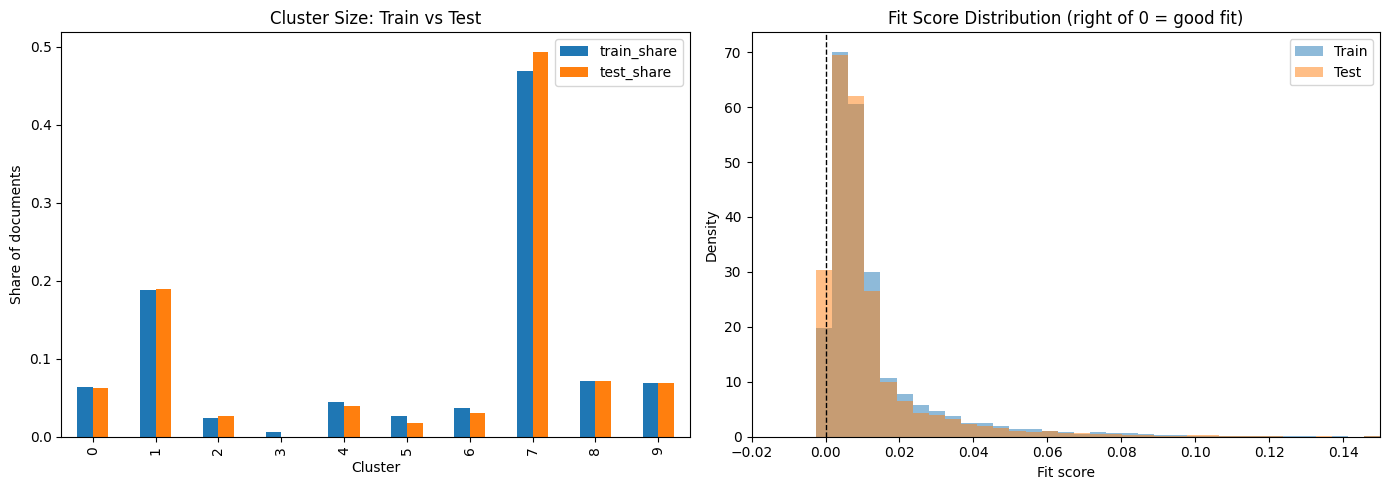

In [93]:
# 6. Visual checks
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bins = np.linspace(-0.02, 0.15, 40)

# a) Are clusters used in the same proportions on new data?
per_cluster[["train_share", "test_share"]].plot(kind="bar", ax=axes[0])
axes[0].set_title("Cluster Size: Train vs Test")
axes[0].set_xlabel("Cluster")
axes[0].set_ylabel("Share of documents")

# b) How well do documents fit their clusters?
axes[1].hist(tr_fit, bins=bins, alpha=0.5, density=True, label="Train")
axes[1].hist(te_fit, bins=bins, alpha=0.5, density=True, label="Test")
axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Fit Score Distribution (right of 0 = good fit)")
axes[1].set_xlabel("Fit score")
axes[1].set_ylabel("Density")
plt.xlim(-0.02, 0.15)
axes[1].legend()

plt.tight_layout()
plt.show()

Explanation:
Left chart: cluster sizes. Each pair of bars shows what share of posts went into each cluster, for training (blue) and test (orange) data. The pairs are almost the same height, so the model sorts new posts the same way it sorted the training posts. Cluster 7, the catch-all, holds about half of both. Cluster 3 (the email-signature cluster) got no test posts.

Right chart: fit scores. The fit score shows how much closer a post is to its own cluster than to the next closest one.

Above 0: the post fits its cluster.
Around 0: the post is on the border between two clusters.
Below 0: the post is closer to another cluster.

Most posts score between 0 and 0.02, so they fit their clusters, but only weakly. A few fall below 0, slightly more in test. The long tail to the right shows the small group of posts that fit very clearly, like encryption or religion posts.

The model is consistent on new data, but most clusters overlap heavily, which is normal for text.

In [94]:
# 7. Best and worst fitting test documents
def show_examples(frame, title):
    print(f"\n{title}")
    for _, row in frame.iterrows():
        print(f"  [cluster {row['cluster']} | fit {row['fit_score']:.3f} | "
              f"true: {row['category']}] {row['text'][:100].strip()!r}")


ranked = test_new.sort_values("fit_score")
show_examples(ranked.tail(5)[::-1], "BEST-FITTING TEST DOCUMENTS")
show_examples(ranked.head(5), "WORST-FITTING TEST DOCUMENTS")

weak_share = (test_new["fit_score"] < 0.05).mean()
print(f"\nShare of test docs with a weak fit (score < 0.05): {weak_share:.1%}")


BEST-FITTING TEST DOCUMENTS
  [cluster 7 | fit 0.477 | true: talk.religion.misc] 'alt.religion.spam?'
  [cluster 7 | fit 0.477 | true: rec.motorcycles] 'Dancing With Idjits.'
  [cluster 7 | fit 0.477 | true: comp.sys.mac.hardware] '-- \n      ____\n  Y_,_|[]|   Ernest Stalnaker\n {|_|_|__|   jcs@sage.cc.purdue.edu\n //oo--OO    ...!pu'
  [cluster 7 | fit 0.477 | true: comp.graphics] 'And for the Commodore CDTV.'
  [cluster 7 | fit 0.477 | true: rec.autos] 'cheek.'

WORST-FITTING TEST DOCUMENTS
  [cluster 1 | fit 0.000 | true: talk.politics.mideast] "I really don't know how you can possibly maintain this hypocritical\nstance.\n\nOn the one hand, you im"
  [cluster 1 | fit 0.000 | true: talk.politics.guns] 'This is quite corect, but a bullet hitting a burned body with little energy\nwill show virtually no'
  [cluster 1 | fit 0.000 | true: comp.graphics] '.. blah blah .. talking about hackers.. you know ..\n\n\nWow!  A new proof for an NP-Complete probl'
  [cluster 4 | fit 0.000 | true: 

Explanation:
The "best" fits are tiny, almost empty posts like "cheek." They score high only because they sit near the catch-all cluster's center, not because they're about a real topic.

The "worst" fits are real posts that mix words from several topics, so they sit between clusters.

96.5% of test posts fit weakly. Removing very short posts before clustering would help.

#Final Analysis:
1. What is TF-IDF and why is it useful for text data?
TF-IDF (Term Frequency–Inverse Document Frequency) turns each document into a vector of word scores. A word scores high when it appears often in one document but rarely across all documents. This highlights topic words like "hockey" or "encryption" and lowers the weight of common words, so documents can be compared by their actual content.

2. What value of K did you use?
K = 5, as required. As an extension, I also tested k = 5 to 30 with the elbow method and silhouette score, and ran k = 10. There was no clear elbow, and silhouette scores stayed very low (0.004–0.011) for every k.

3. What topics did you find in the clusters?
Religion (Cluster 1), Computers (Cluster 2), Sports (Cluster 3), and Politics and encryption (Cluster 4). Cluster 0 was a large general cluster, mostly vehicles and electronics posts mixed with short posts from many other groups.

4. Did the documents within each cluster appear similar?
In the smaller clusters, yes. The sports cluster contained hockey scores and baseball discussions, and the religion cluster was mostly Christian and atheism debates. Cluster 0 was less similar because it held about half of all posts (5,429) from many categories.

5. Were some clusters difficult to interpret?
Yes. Cluster 0 was hard to label because it mixes autos, motorcycles, electronics, and general posts built on everyday words. Cluster 4 combined encryption, Middle East, and gun politics, which are different subjects that share debate-style vocabulary like "government" and "people".

6. What did the PCA visualization show?
Computers and religion spread in opposite directions and were the most separated. Sports extended in its own direction, while the general cluster and the politics cluster overlapped heavily in the center. Two components explained only about 1% of the variance, so the plot shows more overlap than really exists.

7. What is one limitation of using K-Means for text?
K-Means puts each document in exactly one cluster, but many posts mix topics, for example encryption and government policy. It also needs K chosen in advance, and in high-dimensional sparse TF-IDF data the distances between documents are very similar, so clusters overlap (silhouette ≈ 0.004).